
# Querying PUNCH Data

A notebook guide to querying and loading PUNCH data using SunPy.


This notebook provides a guide on how to use tools to query PUNCH data from the VSO / SDAC using Python tools, and how to load and display this data using SunPy.



Load libraries



In [1]:
%%capture
%pip install punchbowl

In [2]:
from sunpy.map import Map
from sunpy.net import Fido
from sunpy.net import attrs as a

## Data querying

With a range of dates and a PUNCH instrument in mind, we can begin querying data. Here we'll consider data from the first two minutes of the first of June, and focus on data from WFI-2 only.

We can construct a query using the Fido tool, specifying search attributes:



In [3]:
time_range = a.Time('2025/06/01 00:00:00', '2025/06/01 00:02:00')
result = Fido.search(time_range, a.Instrument('WFI-2'))
result

Start Time,End Time,Instrument,Wavelength,Provider,Physobs,Wavetype,Extent X,Extent Y,Extent Width,Extent Length,Extent Type,Size
,,,nm,,,,,,,,,Mibyte
Time,Time,str5,float64[2],str10,str9,str7,str7,str7,str17,str16,str11,float64
2025-06-01 00:00:17.000,2025-06-01 00:00:41.000,WFI-2,530.0 .. 530.0,SDAC_PUNCH,intensity,visible,19.6673,14.4731,0.195555552840233,50.0622215270996,FAR_OFF_SUN,1.51074
2025-06-01 00:00:17.000,2025-06-01 00:00:41.000,WFI-2,530.0 .. 530.0,SDAC_PUNCH,intensity,visible,18.8726,14.7681,0.782222211360931,50.0622215270996,FAR_OFF_SUN,6.30371
2025-06-01 00:00:29.000,2025-06-01 00:00:41.000,WFI-2,530.0 .. 530.0,SDAC_PUNCH,intensity,visible,19.6673,14.4731,0.195555552840233,50.0622215270996,FAR_OFF_SUN,1.51074
2025-06-01 00:00:29.000,2025-06-01 00:00:41.000,WFI-2,530.0 .. 530.0,SDAC_PUNCH,intensity,visible,18.9615,14.7091,0.782222211360931,50.0622215270996,FAR_OFF_SUN,6.64941
2025-06-01 00:00:29.000,2025-06-01 00:00:41.000,WFI-2,530.0 .. 530.0,SDAC_PUNCH,intensity,visible,18.9615,14.7091,0.782222211360931,50.0622215270996,FAR_OFF_SUN,6.30859


This results in a table of available data products that match the search criteria.
Next, let's download the first file from this list of results:



In [4]:
files = Fido.fetch(result[0][0])

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

PUNCH_L0_CR2_20250601000029_v0a.fits:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

This returns a list of paths to files that have been downloaded. Note that the Fido.fetch tool can specify a particular download directory for larger data searches.
With that file downloaded, we can load it into a SunPy map object, and display it.



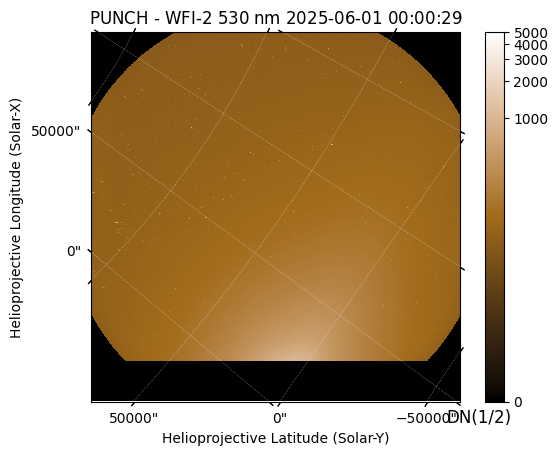

In [5]:
map = Map(files[0])
map.peek(vmin=0, vmax=5000)

And that's it! From here the data is encapsulated into a SunPy map object, which supports that framework for plotting, coordinate transformations, etc.

Of course this is just one path, you could always load the data using Astropy fits tools, load it into an NDCube, or any other FITS-compliant tool.

